In [111]:
import numpy as np
import pandas as pd
import os
import torch
from torchvision import tv_tensors
import matplotlib.pyplot as plt
import pydicom
from PIL import Image
from tqdm import tqdm
import pickle
from copy import deepcopy

DATA_PATH = "D:/ML/RSNA2024"
DEBUG=False

In [112]:
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)

print(f"Using {device} device")

Using cuda device


In [113]:
# CLASSES = ['L1/L2', 'L2/L3', 'L3/L4', 'L4/L5', 'L5/S1']
CLASSES = ['L5/S1', 'Other']
OTHER_CLASSES = ['L4/L5', 'L3/L4', 'L2/L3', 'L1/L2' ]
ALL_CLASSES=['L5/S1', 'L4/L5', 'L3/L4', 'L2/L3', 'L1/L2' ]
values = CLASSES
keys = np.arange(0,len(CLASSES))
IntToClass= dict(zip(keys, values))

classToInt = dict(zip(values, keys))

In [114]:
uniqueSeriesDescr = np.array(['Sagittal T2/STIR', 'Sagittal T1', 'Axial T2'])

if DEBUG:
    dfDescr = pd.read_csv(os.path.join(DATA_PATH, "train_series_descriptions.csv"))
    dfDescr.set_index("study_id", inplace=True)
    allStudyIds = dfDescr.index.unique()
    allStudyIds = allStudyIds[0:30]
else:
    dfDescr = pd.read_csv(os.path.join(DATA_PATH, "test_series_descriptions.csv"))
    dfDescr.set_index("study_id", inplace=True)
    allStudyIds = dfDescr.index.unique()

testStudId = np.random.choice(allStudyIds)

In [115]:
dfDescr.head()

,series_id,series_description
study_id,,
44036939,2828203845,Sagittal T1
44036939,3481971518,Axial T2
44036939,3844393089,Sagittal T2/STIR


In [116]:
from DicomDataset import *

In [117]:
def createScanMapping(studyId):
    seriesIds = dfDescr.loc[studyId]["series_id"].to_numpy()
    seriesDescriptions = dfDescr.loc[studyId]["series_description"].to_numpy()
    scanMapping = []
    for seriesIndex,serId in enumerate(seriesIds):
        seriesDescr = seriesDescriptions[seriesIndex]
        if "Sagittal" in seriesDescr:
            orient = OrientationType.Sagittal
        elif "Axial" in seriesDescr or "Transversal" in seriesDescr:
            orient = OrientationType.Axial
        elif "Frontal" in seriesDescr:
            orient = OrientationType.Frontal
        else:
            orient = OrientationType.Unknown
        if DEBUG:
            folder = os.path.join(DATA_PATH, f"train_images/{studyId}/{serId}")
        else:
            folder = os.path.join(DATA_PATH, f"test_images/{studyId}/{serId}")
        scanMapping.append((orient, folder))
    return scanMapping

In [118]:
vertebraeDetector = torch.load(os.path.join(DATA_PATH, "VertebraeDetectorBinary_epoch129_mAP0.5763.pth"))
vertebraeDetector.to(device)
vertebraeDetector.eval()

C:\Users\manue\AppData\Local\Temp\ipykernel_5392\3410995556.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  vertebraeDetector = torch.load(os.path.join(DATA_PATH, "Verte

RetinaNet(
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      

In [119]:
import matplotlib.patches as patches


def plotImageWithAnnot(im, target, filename=None):
    fig, ax = plt.subplots()
    imsh = ax.imshow(im)
    fig.colorbar(imsh, ax=ax)

    for idx,b in enumerate(target["boxes"]):
        b = b.numpy()
        rect = patches.Rectangle((b[0], b[1]), b[2]-b[0], b[3]-b[1], linewidth=1, edgecolor='r', facecolor='none')
        ax.add_patch(rect)
        plt.text(b[0], b[1]-4, IntToClass[target["labels"].numpy()[idx]], {"color":"red"})
    if filename:
        plt.title(filename)
        plt.tight_layout()
        plt.savefig(os.path.join(DATA_PATH, f"objDetExamples/{filename}.png"), dpi=120)
        plt.close()
    else:
        plt.show()

def plotImageWithBB(im, boundingBoxes, labels=None, filename=None):
    fig, ax = plt.subplots()
    imsh = ax.imshow(im)
    fig.colorbar(imsh, ax=ax)

    for idx,b in enumerate(boundingBoxes):
        b = b.numpy()
        rect = patches.Rectangle((b[0], b[1]), b[2]-b[0], b[3]-b[1], linewidth=1, edgecolor='r', facecolor='none')
        ax.add_patch(rect)
        if not labels==None:
            plt.text(b[0], b[1]-4, IntToClass[labels.numpy()[idx]], {"color":"red"})
    if filename:
        plt.title(filename)
        plt.tight_layout()
        plt.savefig(os.path.join(DATA_PATH, f"objDetExamples/{filename}.png"), dpi=120)
        plt.close()
    else:
        plt.show()

In [120]:
def filterBoundingBoxes(targets, threshold=0.7):
    if type(targets)!=list:
        raise ValueError("targets has to be a list of dictionaries containing {'boxes':..., 'scores':..., 'labels':...}")
    filteredBB=[]
    for target in targets:
        scores = target["scores"].detach().cpu().numpy()
        boxes = target["boxes"].detach().cpu().numpy()
        labels = [IntToClass[el] for el in target["labels"].detach().cpu().numpy()]

        filtered={}
        newScores=[]

        for c in CLASSES:
            classIdxs = np.argwhere(np.array(labels)==c).flatten()
            if classIdxs.shape[0]==0:
                continue
            highestScore  = scores[classIdxs][0]
            if highestScore>threshold:
                filtered[c] = boxes[classIdxs[0]]
                newScores.append(highestScore)
        filteredBB.append({"filteredBB": filtered, "scores": newScores})
    return filteredBB



# testTar =[{'boxes': torch.tensor([[277.0559, 480.4082, 342.5710, 546.4760],
#           [246.1063, 421.0921, 322.0190, 465.9918],
#           [232.9959, 355.6693, 310.8026, 393.1955],
#           [235.5022, 282.2717, 309.8636, 314.1367],
#           [240.6923, 209.3363, 311.7209, 240.0908],
#           [240.8825, 210.6963, 311.3056, 239.0509],
#           [366.7859, 303.0891, 401.7643, 343.1634],
#           [244.8488, 142.8043, 313.3584, 171.8768],
#           [233.2152, 355.9161, 310.8337, 393.3716],
#           [277.0559, 480.4082, 342.5710, 546.4760],
#           [245.6599, 420.8578, 322.0050, 465.7909],
#           [362.5488, 364.8280, 410.1449, 413.4319],
#           [366.9376, 302.8406, 401.8413, 342.6856],
#           [366.8237, 302.9432, 401.6767, 343.5234]]),
#   'scores': torch.tensor([1.0000, 0.9999, 0.9998, 0.9985, 0.8368, 0.4317, 0.3369, 0.1112, 0.0953,
#           0.0714, 0.0698, 0.0658, 0.0620, 0.0581]),
#   'labels': torch.tensor([4, 3, 2, 1, 0, 1, 3, 0, 1, 3, 2, 4, 4, 0])}]

# filterBoundingBoxes(testTar)

In [121]:
def filterBoundingBoxesBinary(targets, threshold=0.9):
    if type(targets)!=list:
        raise ValueError("targets has to be a list of dictionaries containing {'boxes':..., 'scores':..., 'labels':...}")
    filteredBB=[]
    for target in targets:
        scores = target["scores"].detach().cpu().numpy()
        boxes = target["boxes"].detach().cpu().numpy()
        labels = [IntToClass[el] for el in target["labels"].detach().cpu().numpy()]

        output={}
        outputScores=[]

        if not "L5/S1" in labels:
            # No L5 found -> no assignment of all the other vertebrae possible
            filteredBB.append({})
            continue

        #Get L5/S1 with the highest score
        classIdxs = np.argwhere(np.array(labels)=="L5/S1").flatten()
        l5Scores  = np.array(scores)[classIdxs]
        l5Boxes = np.array(boxes)[classIdxs]
        highestL5ScoreIdx = np.argmax(l5Scores).flatten()
        l5Box = l5Boxes[highestL5ScoreIdx][0]
        l5Score = l5Scores[highestL5ScoreIdx]
        if l5Score<threshold:
            filteredBB.append({})
            continue
        output["L5/S1"] = {'filteredBB': l5Box, 'score': l5Score[0]}

        #Get all Other vertebrae with score > threshold
        classIdxs = np.argwhere((np.array(labels)=="Other") & (np.array(scores)>threshold)).flatten()
        otherBoxes = np.array(boxes)[classIdxs]
        otherScores = np.array(scores)[classIdxs]
        
        #Sort ascending by difference in y direction of the boxes to the L5 Box 
        yDistanceToL5 = [l5Box[3] - el[3] for el in otherBoxes]
        sortedIdxs = np.argsort(yDistanceToL5)
        otherBoxesSorted = otherBoxes[sortedIdxs]
        otherScoresSorted = otherScores[sortedIdxs]
        yDistanceToL5Sorted = np.array(yDistanceToL5)[sortedIdxs]


        levelIdx=0
        for i,otherBox in enumerate(otherBoxesSorted):
            if len(output.keys())==len(ALL_CLASSES):
                #Found all
                break
            if yDistanceToL5Sorted[i]<20:
                #If the other box is below or very close to L5, assume its detected as L5/S1 and another one simultaneously
                continue
            output[OTHER_CLASSES[levelIdx]]={'filteredBB': otherBox, 'score': otherScoresSorted[i]}
            levelIdx += 1
        filteredBB.append(output)
    return filteredBB





testTar =[{'boxes': torch.tensor([[277.0559, 480.4082, 342.5710, 546.4760],
          [246.1063, 421.0921, 322.0190, 465.9918],
          [232.9959, 355.6693, 310.8026, 393.1955],
          [235.5022, 282.2717, 309.8636, 314.1367],
          [240.6923, 209.3363, 311.7209, 240.0908],
          [240.8825, 210.6963, 311.3056, 239.0509],
          [366.7859, 303.0891, 401.7643, 343.1634],
          [244.8488, 142.8043, 313.3584, 171.8768],
          [233.2152, 355.9161, 310.8337, 393.3716],
          [277.0559, 480.4082, 342.5710, 546.4760],
          [245.6599, 420.8578, 322.0050, 465.7909],
          [362.5488, 364.8280, 410.1449, 413.4319],
          [366.9376, 302.8406, 401.8413, 342.6856],
          [366.8237, 302.9432, 401.6767, 343.5234]]),
  'scores': torch.tensor([1.0000, 0.9999, 0.9998, 0.9985, 0.8368, 0.4317, 0.3369, 0.1112, 0.0953,
          0.0714, 0.0698, 0.0658, 0.0620, 0.0581]),
  'labels': torch.tensor([0,0,1,1,1,1,1,1,1,1,1,1,1,1])}]

filterBoundingBoxesBinary(testTar)

[{'L5/S1': {'filteredBB': array([277.0559, 480.4082, 342.571 , 546.476 ], dtype=float32),
   'score': 1.0},
  'L4/L5': {'filteredBB': array([232.9959, 355.6693, 310.8026, 393.1955], dtype=float32),
   'score': 0.9998},
  'L3/L4': {'filteredBB': array([235.5022, 282.2717, 309.8636, 314.1367], dtype=float32),
   'score': 0.9985}}]

In [122]:
def extractPatch(im:np.array, bb, extensionFactor=0.0):
    # bb format: x1,y1,x2,y2
    if len(im.shape)!=2:
        raise ValueError(f"im has to be of shape (width, height) instead of {im.shape}")
    bbExt = [*bb]
    if extensionFactor>0:
        bbExt[0], bbExt[1] = np.clip(bbExt[0]*(1-extensionFactor), 0, im.shape[1]), np.clip(bbExt[1]*(1-extensionFactor), 0, im.shape[1])
        bbExt[2], bbExt[3] = np.clip(bbExt[2]*(1+extensionFactor), 0, im.shape[0]), np.clip(bbExt[3]*(1+extensionFactor), 0, im.shape[0])
    bbExt = [int(np.round(el)) for el in bbExt]
    # np array has height x width !
    return im[bbExt[1]:bbExt[3], bbExt[0]:bbExt[2]]

def extendBoundingBox(im:np.array, bb, extensionFactor=0.0):
    # bb format: x1,y1,x2,y2
    if len(im.shape)!=2:
        raise ValueError(f"im has to be of shape (width, height) instead of {im.shape}")
    bbExt = [*bb]
    if extensionFactor>0:
        bbExt[0], bbExt[1] = np.clip(bbExt[0]*(1-extensionFactor), 0, im.shape[1]), np.clip(bbExt[1]*(1-extensionFactor), 0, im.shape[1])
        bbExt[2], bbExt[3] = np.clip(bbExt[2]*(1+extensionFactor), 0, im.shape[0]), np.clip(bbExt[3]*(1+extensionFactor), 0, im.shape[0])
    bbExt = [int(np.round(el)) for el in bbExt]
    return bbExt

In [123]:
with torch.no_grad():
    allData = {}
    for studyId in tqdm(allStudyIds):
        scanMapping = createScanMapping(studyId)
        patData = PatientData(scanMapping)
        sagScans = patData.getSagittalScans()
        sagittalPatches=dict(zip(ALL_CLASSES, [ [] for _ in range(len(ALL_CLASSES)) ]))
        axScans = patData.getAxialScans()
        axSlices=dict(zip(ALL_CLASSES, [ [] for _ in range(len(ALL_CLASSES)) ]))
        axSlicesExtracted = False
        
        for s in sagScans:
            for slice in s.slices:
                # im = torch.tensor(slice.data.astype(np.float32)/255.0).to(device)
                im = tv_tensors.Image(slice.data.astype(np.float32)/255.0).to(device)
                targets = vertebraeDetector([im])
                filteredBoundingBoxesList = filterBoundingBoxesBinary(targets, 0.95)
                filteredBoundingBoxes = filteredBoundingBoxesList[0]
                if len(filteredBoundingBoxes.keys())==0:
                    #No vertebrae visible
                    continue

                # Get sagittal patches
                for cl in filteredBoundingBoxes.keys():
                    bb = filteredBoundingBoxes[cl]["filteredBB"]
                    patch = extractPatch(im.detach().cpu().numpy()[0,:,:], bb, 0.1)
                    sagittalPatches[cl].append((patch*255).astype(np.uint8))

                # Get axial slices
                # allLevelsVisible = np.all([el in list(filteredBoundingBoxes.keys()) for el in CLASSES])
                allLevelsVisible = np.all([el in list(filteredBoundingBoxes.keys()) for el in ALL_CLASSES])
                axSlicesTemp = {}
                if allLevelsVisible and not axSlicesExtracted:
                    #If there are bounding boxes of all 5 levels
                    #Get the slices that are in the range of that bounding box
                    for cl in filteredBoundingBoxes.keys():
                        bb = filteredBoundingBoxes[cl]["filteredBB"]
                        bb = extendBoundingBox(im.detach().cpu().numpy()[0,:,:], bb, 0.1)
                        startPos = slice.getWorldPosition(0,bb[3])
                        endPos = slice.getWorldPosition(0,bb[1])
                        for axScan in axScans:
                            axSlicesInRange = patData.getSlicesInRangeDirection(axScan, startPos, endPos, Direction.Z)
                            if len(axSlicesInRange)<1:
                                #Didnt find enough slices -> continue
                                # axSlicesTemp[cl] = []
                                continue
                            else:
                                axSlices[cl].append(axSlicesInRange)

                    # allLevelsDetected = np.all([el in list(axSlicesTemp.keys()) for el in ALL_CLASSES])
                    # if allLevelsDetected:
                    # axSlices = deepcopy(axSlicesTemp)
                    axSlicesExtracted=True
                    foundLevels = [len(axSlices[k])>=1 for k in list(axSlices.keys())]
        if not np.all(foundLevels) :
            print(f"Not all axial slices found for {studyId}: {np.array(list(axSlices.keys()))[foundLevels]}")
        allData[studyId] = {"axSlices": axSlices, "sagittalPatches": sagittalPatches}



100%|██████████| 1/1 [00:02<00:00,  2.82s/it]


In [124]:
# Plot all BBs
# plotImageWithBB(im.detach().cpu().numpy()[0,:,:], [torch.tensor(filteredBoundingBoxes[el]["filteredBB"]) for el in ALL_CLASSES], torch.tensor([0,1,1,1,1]))

# Plot current BB
# plotImageWithBB(im.detach().cpu()[0,:,:], torch.tensor([bb]))

#Visualize 3D world
# Visualize3DPointsAndSlices([[startPos],[endPos], [s.getWorldPosition(s.data.shape[0]//2, s.data.shape[1]//2) for s in patData.getAxialScans()[0].slices]], sliceList=patData.getAxialScans()[0].slices)

In [125]:
labelMapping = {"Normal/Mild": 0, "Moderate":1, "Severe":2}
ALL_CLASSES=['L5/S1', 'L4/L5', 'L3/L4', 'L2/L3', 'L1/L2' ]

class Level(Enum):
    L5_S1 = 'L5/S1'
    L4_L5 = 'L4/L5'
    L3_L4 = 'L3/L4'
    L2_L3 = 'L2/L3'
    L1_L2 = 'L1/L2'

LEVEL = Level.L1_L2

In [126]:
values = ALL_CLASSES
keys = np.arange(0,len(ALL_CLASSES))
IntToClass= dict(zip(keys, values))

classToInt = dict(zip(values, keys))

In [127]:
CONDITIONS = ['spinal_canal_stenosis', 'left_neural_foraminal_narrowing','right_neural_foraminal_narrowing','left_subarticular_stenosis', 'right_subarticular_stenosis']
print(f"Possible conditions per level: {CONDITIONS}")


Possible conditions per level: ['spinal_canal_stenosis', 'left_neural_foraminal_narrowing', 'right_neural_foraminal_narrowing', 'left_subarticular_stenosis', 'right_subarticular_stenosis']


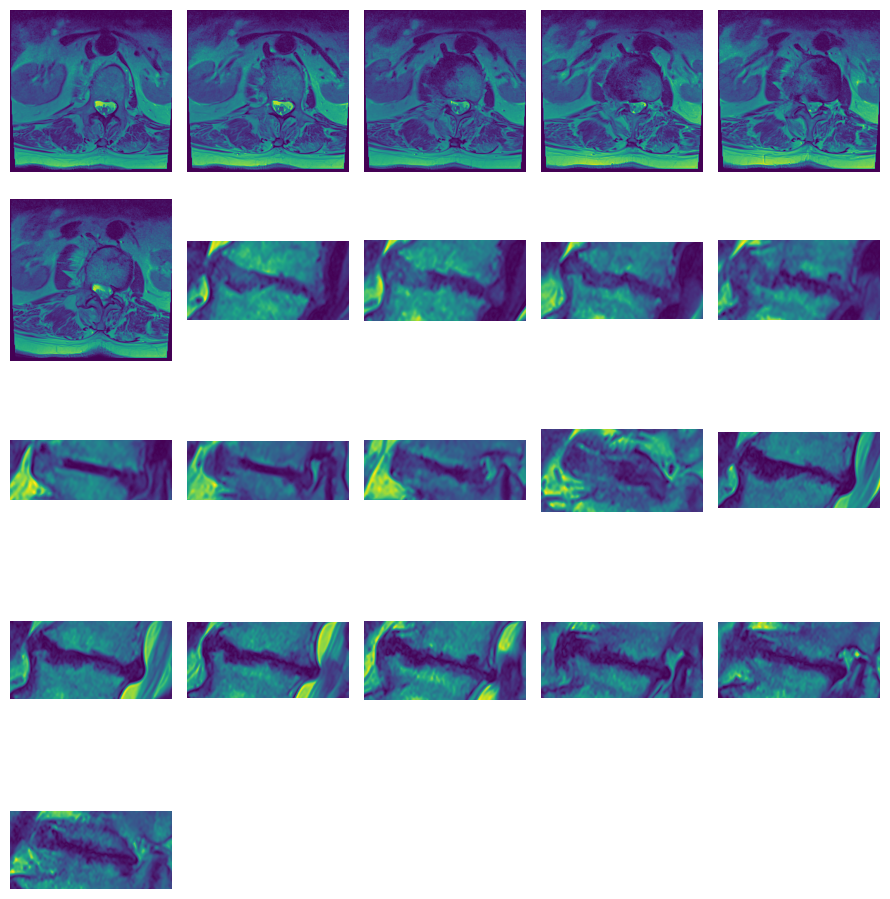

In [128]:
def plotAllData(instance, figsize=(9,10)):
    numIm = len(instance["axSlices"][LEVEL.value][0]) + len(instance["sagittalPatches"][LEVEL.value])
    imCount = int(np.ceil(np.sqrt(numIm))) 
    plt.figure(figsize=figsize)
    i=0
    for i, im in enumerate(instance["axSlices"][LEVEL.value][0]):
        plt.subplot(imCount,imCount,i+1)
        plt.imshow(im.data)
        plt.axis("off")
        plt.tight_layout()
    for j,im in enumerate(instance["sagittalPatches"][LEVEL.value]):
        plt.subplot(imCount,imCount,i+j+1)
        plt.imshow(im)
        plt.axis("off")
        plt.tight_layout()

plotAllData(allData[testStudId])

In [129]:
del vertebraeDetector

## Data

In [130]:
from threading import Thread
from concurrent.futures import ThreadPoolExecutor
numWorkers=16

import albumentations as A

IMG_SIZE = (420, 420)

centerCropFactor=0.7
upScaleFactor = 1/centerCropFactor
upscaledImgSize = [int(IMG_SIZE[0]*upScaleFactor), int(IMG_SIZE[1]*upScaleFactor)]

transformsVal = A.Compose([
    A.Resize(upscaledImgSize[0], upscaledImgSize[1]),
    A.Crop(upscaledImgSize[0]//2, int(upscaledImgSize[1]*0.1), upscaledImgSize[0], int(upscaledImgSize[1]*0.8)),
    A.Resize(IMG_SIZE[0], IMG_SIZE[1]),
    A.Normalize(max_pixel_value=1.0)
])

transformsValWithCenterCrop = A.Compose([
    A.Resize(int(IMG_SIZE[0]*1/centerCropFactor), int(IMG_SIZE[1]*1/centerCropFactor)),
    A.CenterCrop(int(IMG_SIZE[0]*centerCropFactor), int(IMG_SIZE[1]*centerCropFactor)),
    A.Resize(IMG_SIZE[0], IMG_SIZE[1]),
    A.Normalize(max_pixel_value=1.0)
])


numSagSlices=20
numAxSlices=10
DEPTH = numSagSlices+numAxSlices

def transf(imArray, imArrayIdx, centerCrop=False, validate=False):
    imArray[imArrayIdx] = imArray[imArrayIdx]/255.0
    if validate and centerCrop:
        imArray[imArrayIdx] = transformsValWithCenterCrop(image=imArray[imArrayIdx])["image"]
    elif validate:
        imArray[imArrayIdx] = transformsVal(image=imArray[imArrayIdx])["image"]




def transformAsyncPool(pool, imList, centerCrop=False, validate=False):
    results=[]
    for idx, im in enumerate(imList):
        results.append(pool.submit(transf, imList, idx, centerCrop, validate))
    for r in results:
        r.result()



def generatorVal():
    with ThreadPoolExecutor(numWorkers) as valPool:
        for valStudyId in allStudyIds:
            for level in list(Level):
                instanceVal = allData[valStudyId]
                axSlicesVal = []
                for axs in instanceVal["axSlices"][level.value]:
                    for sl in axs:
                        axSlicesVal.append(sl)
                sagSlicesVal=[el.astype(np.float32) for el in instanceVal["sagittalPatches"][level.value]]
                imListAxialVal = [im.data.astype(np.float32) for im in axSlicesVal]
                transformAsyncPool(valPool, sagSlicesVal, False, True)
                transformAsyncPool(valPool, imListAxialVal, True,  True)
                imArrayVal = np.zeros((numSagSlices+numAxSlices, *IMG_SIZE))
                for iSag in range(numSagSlices):
                    if iSag<len(sagSlicesVal):
                        imArrayVal[iSag, :, :] = sagSlicesVal[iSag]
                for iAx in range(numAxSlices):
                    if iAx<len(imListAxialVal):
                        imArrayVal[numSagSlices+iAx, :, :] = imListAxialVal[iAx]
                imVal = torch.Tensor(imArrayVal)
                yield imVal, level.value, valStudyId


gVal = generatorVal()
testInstanceVal = next(gVal)

In [131]:
def plotAll(imArr, figsize=(9,10)):
    numIm = imArr.shape[0]
    imCount = int(np.ceil(np.sqrt(numIm))) 
    plt.figure(figsize=figsize)
    for i in range(imCount**2):
        if i<imArr.shape[0]:
            plt.subplot(imCount,imCount,i+1)
            plt.imshow(imArr[i,:,:])
        plt.axis("off")
        plt.tight_layout()

tensor(-2.1179) tensor(2.2318)
torch.Size([30, 420, 420])
L4/L5


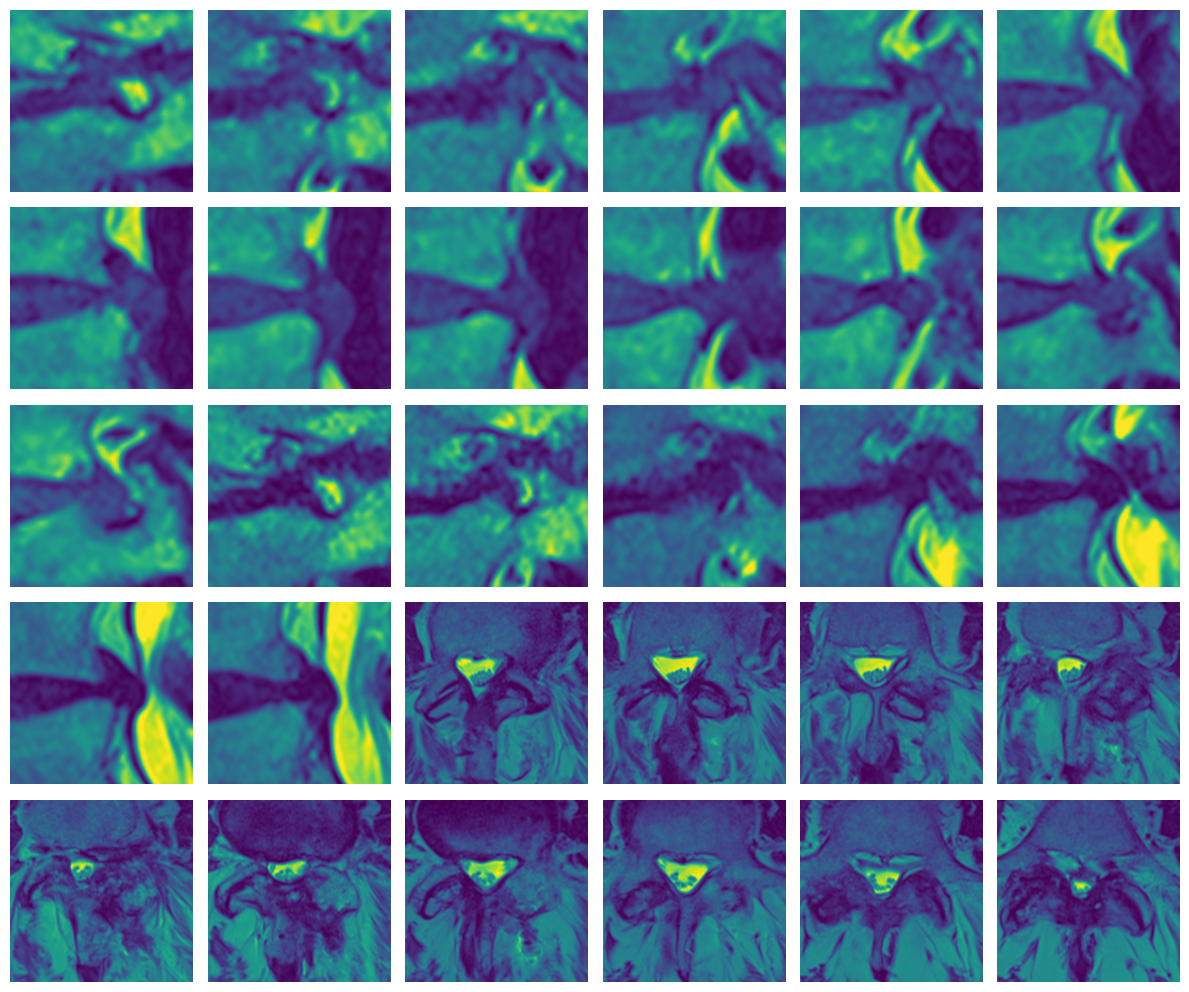

In [132]:

testInstance = next(gVal)

plotAll(testInstance[0].numpy(), (12,12))

print(torch.min(testInstance[0]), torch.max(testInstance[0]))
print(testInstance[0].shape)
print(testInstance[1])

In [133]:
BATCH_SIZE = 8

class IterDataset(torch.utils.data.IterableDataset):
    def __init__(self, generator, length):
        self.generator = generator
        self.len = length

    def __iter__(self):
        return self.generator()
    
    def __len__(self):
        return self.len
    

datasetVal = IterDataset(generatorVal, len(allStudyIds)*len(list(Level)))

valLoader = torch.utils.data.DataLoader(datasetVal, batch_size=BATCH_SIZE, shuffle=False)

In [134]:
for XData, lev, studid in valLoader:
    print(f"Shape of X: {XData.shape} {XData.dtype}")
    print("Max and Min: ", torch.max(XData), torch.min(XData))
    break

Shape of X: torch.Size([5, 30, 420, 420]) torch.float32
Max and Min:  tensor(2.2318) tensor(-2.1179)


In [135]:
import timm

use_amp = True


class Classifier(torch.nn.Module):
    def __init__(self, backbone):
        super(Classifier, self).__init__()
        self.basemodel = timm.create_model(backbone, pretrained=True, num_classes=len(CONDITIONS)*len(labelMapping), in_chans=DEPTH)
        self.name=f"DepthClassifier_{backbone}"

    def forward(self, x):
        x = self.basemodel(x)
        x = torch.reshape(x, (x.shape[0], len(labelMapping), len(CONDITIONS)))
        return x


# model = Classifier("caformer_s36")
model = Classifier("edgenext_base")
# model = Classifier("densenet169")
# model = Classifier("resnet101d")

model = model.to(device)


# checkpoint = torch.load(os.path.join(DATA_PATH, "DepthClassifier_resnet101d_420_F1_0.542_CE_0.657_epoch_3.pt"), map_location=device)
# print(model.load_state_dict(checkpoint['model_state_dict']))

with open(os.path.join(DATA_PATH, "cvResults.pkl"), 'rb') as f:
    cvResults = pickle.load(f)

In [136]:
from scipy.special import softmax

entriesAll = []

for cvRes in tqdm(cvResults):
    entries = []

    model.load_state_dict(cvRes["bestWeights"])
    model.eval()
    model.to(device)

    num_batches = len(valLoader)
    
    with torch.no_grad():
        for i, (XVal, levVal, studyIdsVal) in enumerate(valLoader):
            XVal = XVal.to(device)
            predVal = model(XVal)
            # probs = softmax(predVal.detach().cpu().numpy(), 1)
            for levIdx, level in enumerate(levVal):
                for condIdx, cond in enumerate(CONDITIONS):
                    prob = predVal.detach().cpu().numpy()[levIdx,:, condIdx] 
                    entries.append([f"{studyIdsVal[levIdx]}_{cond}_{level.lower().replace("/", "_")}", *prob])

    entriesAll.append(entries)


print("Done!")

100%|██████████| 5/5 [00:01<00:00,  3.03it/s]

Done!


In [137]:
print(np.array(entriesAll).shape)
entryValues = np.array(entriesAll)[:,:,1::]
avrEntryValues = np.mean(entryValues.astype(np.float32), axis=0)
print(np.mean(entryValues[:,0,0].astype(np.float32)))
print(avrEntryValues)
avrEntryValues = softmax(avrEntryValues, 1)
print(avrEntryValues)

(5, 25, 4)
1.2906861
[[ 1.2906861  -0.46831432 -0.74403095]
 [-0.97383165  0.29810894  0.4539408 ]
 [-0.44047746  0.43327904  0.22881679]
 [-0.63387024  0.21783462  0.2747198 ]
 [-0.8744127   0.28688663  0.37254277]
 [-0.1952619   0.01813842  0.4537022 ]
 [-1.1367722   0.6123557   0.6289238 ]
 [-0.8831248   0.760083    0.55861217]
 [-1.6559985   0.25591525  1.4048201 ]
 [-1.963261    0.2604058   1.4626379 ]
 [ 0.78631085 -0.07729221 -0.6367595 ]
 [-0.62318337  0.43840247  0.08686361]
 [-0.289006    0.5263856  -0.00573629]
 [-0.6256695   0.17323828  0.28890464]
 [-0.8768412   0.2719519   0.49781626]
 [ 0.23704977  0.15777542 -0.4328065 ]
 [-0.12737083  0.40468937 -0.3978419 ]
 [ 0.16186766  0.35216665 -0.46387568]
 [-0.50421226  0.14730257  0.2419379 ]
 [-0.74392027  0.19885401  0.39752838]
 [-0.9276371   0.62167865  0.5128182 ]
 [-0.22570817  0.64940476 -0.4112332 ]
 [-0.03165492  0.54525423 -0.1980586 ]
 [-1.1676458   0.19873877  0.96089906]
 [-1.3931042   0.3115718   1.0283253 ]]
[[0

In [138]:
allLabels = np.array(entriesAll)[0,:,0]
print(allLabels.shape, avrEntryValues.shape)
avrEntries = np.concatenate((allLabels.reshape(allLabels.shape[0], 1), avrEntryValues.astype("<U47")), axis=1)
print(avrEntries.shape)
avrEntries

(25,) (25, 3)
(25, 4)


array([['44036939_spinal_canal_stenosis_l5_s1', '0.7674983', '0.1321762',
        '0.10032543'],
       ['44036939_left_neural_foraminal_narrowing_l5_s1', '0.114453524',
        '0.4083438', '0.4772027'],
       ['44036939_right_neural_foraminal_narrowing_l5_s1', '0.18695946',
        '0.4479351', '0.3651054'],
       ['44036939_left_subarticular_stenosis_l5_s1', '0.1716897',
        '0.4023787', '0.42593166'],
       ['44036939_right_subarticular_stenosis_l5_s1', '0.13031329',
        '0.4162312', '0.45345548'],
       ['44036939_spinal_canal_stenosis_l4_l5', '0.24088041',
        '0.29818103', '0.4609385'],
       ['44036939_left_neural_foraminal_narrowing_l4_l5', '0.079395175',
        '0.45648935', '0.46411553'],
       ['44036939_right_neural_foraminal_narrowing_l4_l5', '0.09615601',
        '0.49729317', '0.40655082'],
       ['44036939_left_subarticular_stenosis_l4_l5', '0.03435122',
        '0.23242123', '0.73322755'],
       ['44036939_right_subarticular_stenosis_l4_l5', '0.02

In [139]:
dfSubmission = pd.DataFrame(avrEntries, columns=["row_id","normal_mild","moderate","severe"])
dfSubmission.head(20)

,row_id,normal_mild,moderate,severe
0,44036939_spinal_canal_stenosis_l5_s1,0.7674983,0.1321762,0.10032543
1,44036939_left_neural_foraminal_narrowing_l5_s1,0.114453524,0.4083438,0.4772027
2,44036939_right_neural_foraminal_narrowing_l5_s1,0.18695946,0.4479351,0.3651054
3,44036939_left_subarticular_stenosis_l5_s1,0.1716897,0.4023787,0.42593166
4,44036939_right_subarticular_stenosis_l5_s1,0.13031329,0.4162312,0.45345548
5,44036939_spinal_canal_stenosis_l4_l5,0.24088041,0.29818103,0.4609385
6,44036939_left_neural_foraminal_narrowing_l4_l5,0.079395175,0.45648935,0.46411553
7,44036939_right_neural_foraminal_narrowing_l4_l5,0.09615601,0.49729317,0.40655082
8,44036939_left_subarticular_stenosis_l4_l5,0.03435122,0.23242123,0.73322755
9,44036939_right_subarticular_stenosis_l4_l5,0.024395345,0.22544114,0.75016356


In [140]:
dfSubmission.to_csv("submission.csv", index=False)